#### Importation des bibliothèques

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


#### Chargement des données

In [2]:

data = pd.read_excel("data/processed/orbit_dataset_engineering.xlsx")

print("Dimensions :", data.shape)

data.head()

Dimensions : (116720, 51)


,id_point,date_collecte,latitude,longitude,fillRate,fillRate_t_minus_1,fillRate_t_minus_2,delta_fillRate_24h,rolling_mean_3d,fillRate_target_t_plus_1,...,quartier_14,rendement_remplissage,pression_citoyenne,ratio_plaintes,indice_meteo,pression_collecte,charge_precollecteur,indice_saturation,indice_priorite,risque_debordement
0,0,2022-01-03,4.001501,9.73807,49.55,33.98,12.98,15.58,32.17,6.00,...,False,133.328571,0,0.0,1714.44,99.10,16.516667,908846.10,0.0,1594.0235
1,0,2022-01-04,4.001501,9.73807,6.00,49.55,33.98,-43.56,29.84,21.43,...,False,15.371429,0,0.0,2052.27,0.00,3.000000,110052.00,0.0,179.0400
2,0,2022-01-05,4.001501,9.73807,21.43,6.00,49.55,15.43,25.66,36.56,...,False,55.434286,0,0.0,1916.20,21.43,10.715000,393069.06,0.0,549.8938
3,0,2022-01-06,4.001501,9.73807,36.56,21.43,6.00,15.13,21.33,52.21,...,False,96.278571,0,0.0,2138.16,73.12,9.140000,670583.52,0.0,779.8248
4,0,2022-01-07,4.001501,9.73807,52.21,36.56,21.43,15.65,36.73,72.72,...,False,139.950000,0,0.0,1740.92,156.63,13.052500,957635.82,0.0,1917.6733


#### Vérification des types

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116720 entries, 0 to 116719
Data columns (total 51 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id_point                        116720 non-null  int64         
 1   date_collecte                   116720 non-null  datetime64[ns]
 2   latitude                        116720 non-null  float64       
 3   longitude                       116720 non-null  float64       
 4   fillRate                        116720 non-null  float64       
 5   fillRate_t_minus_1              116720 non-null  float64       
 6   fillRate_t_minus_2              116720 non-null  float64       
 7   delta_fillRate_24h              116720 non-null  float64       
 8   rolling_mean_3d                 116720 non-null  float64       
 9   fillRate_target_t_plus_1        116720 non-null  float64       
 10  nb_signalements_citoyens        116720 non-null  int64  

#### Statistiques descriptives

In [4]:
data.describe()

,id_point,date_collecte,latitude,longitude,fillRate,fillRate_t_minus_1,fillRate_t_minus_2,delta_fillRate_24h,rolling_mean_3d,fillRate_target_t_plus_1,...,priorite_recommandee,rendement_remplissage,pression_citoyenne,ratio_plaintes,indice_meteo,pression_collecte,charge_precollecteur,indice_saturation,indice_priorite,risque_debordement
count,116720.000000,116720,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,...,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,116720.000000,1.167200e+05,116720.000000,116720.000000
mean,39.500000,2024-01-02 00:00:00,4.045566,9.702375,23.951267,23.955521,23.955589,-0.004248,23.954139,23.949255,...,0.388862,67.058597,0.065319,0.004204,2047.534158,64.375819,6.993279,3.534538e+05,4.354230,754.151334
min,0.000000,2022-01-03 00:00:00,3.940558,9.570896,2.000000,2.000000,2.000000,-97.380000,2.340000,2.000000,...,0.000000,4.585556,0.000000,0.000000,1248.360000,0.000000,0.251250,8.202920e+03,0.000000,5.499000
25%,19.750000,2023-01-02 00:00:00,4.010506,9.674735,10.230000,10.230000,10.230000,-4.242500,13.540000,10.230000,...,0.000000,28.566187,0.000000,0.000000,1871.100000,0.000000,1.940000,1.107884e+05,0.000000,151.484300
50%,39.500000,2024-01-02 00:00:00,4.044230,9.698916,18.410000,18.410000,18.420000,6.910000,20.260000,18.410000,...,0.000000,51.350652,0.000000,0.000000,2051.900000,19.420000,3.946667,2.359034e+05,0.000000,344.350750
75%,59.250000,2025-01-01 00:00:00,4.075389,9.730496,33.490000,33.510000,33.510000,11.130000,31.190000,33.490000,...,0.000000,93.705598,0.000000,0.000000,2222.220000,78.560000,8.510000,4.829448e+05,0.000000,828.059350
max,79.000000,2025-12-31 00:00:00,4.179424,9.800674,99.500000,99.500000,99.500000,36.810000,99.500000,99.500000,...,3.000000,317.085000,7.000000,2.000000,2920.500000,1293.500000,99.500000,2.396856e+06,619.920000,9900.250000
std,23.092305,NaN,0.048222,0.044429,18.388678,18.390353,18.388312,19.309115,13.841490,18.385681,...,0.832518,51.657574,0.319652,0.061607,231.676917,106.510332,8.954446,3.402066e+05,22.918973,1075.725732


###  Analyse de la variable cible

#### Notre variable cible est: fillRate_target_t_plus_1

#### C'est elle que les modèles devront prédire.

#### Distribution

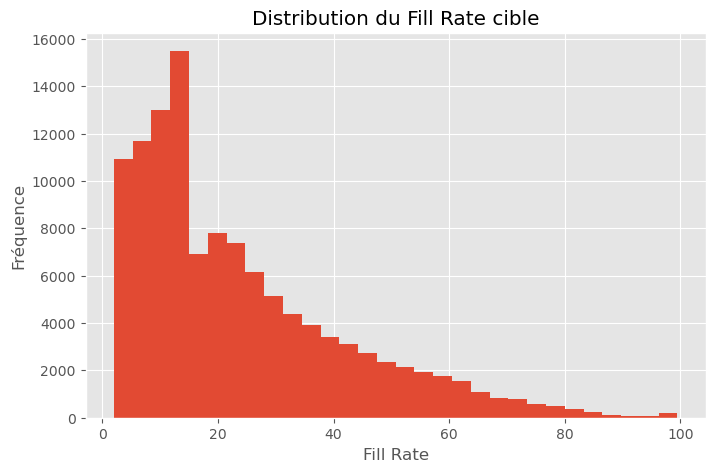

In [5]:

plt.figure(figsize=(8,5))

plt.hist(
    data["fillRate_target_t_plus_1"],
    bins=30
)

plt.title("Distribution du Fill Rate cible")

plt.xlabel("Fill Rate")

plt.ylabel("Fréquence")

plt.show()

#### Boxplot

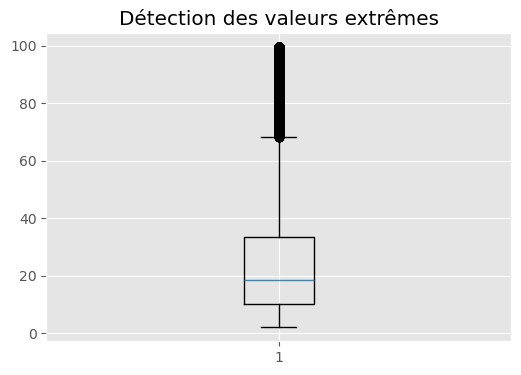

In [6]:

plt.figure(figsize=(6,4))

plt.boxplot(data["fillRate_target_t_plus_1"])

plt.title("Détection des valeurs extrêmes")

plt.show()

#### Corrélations

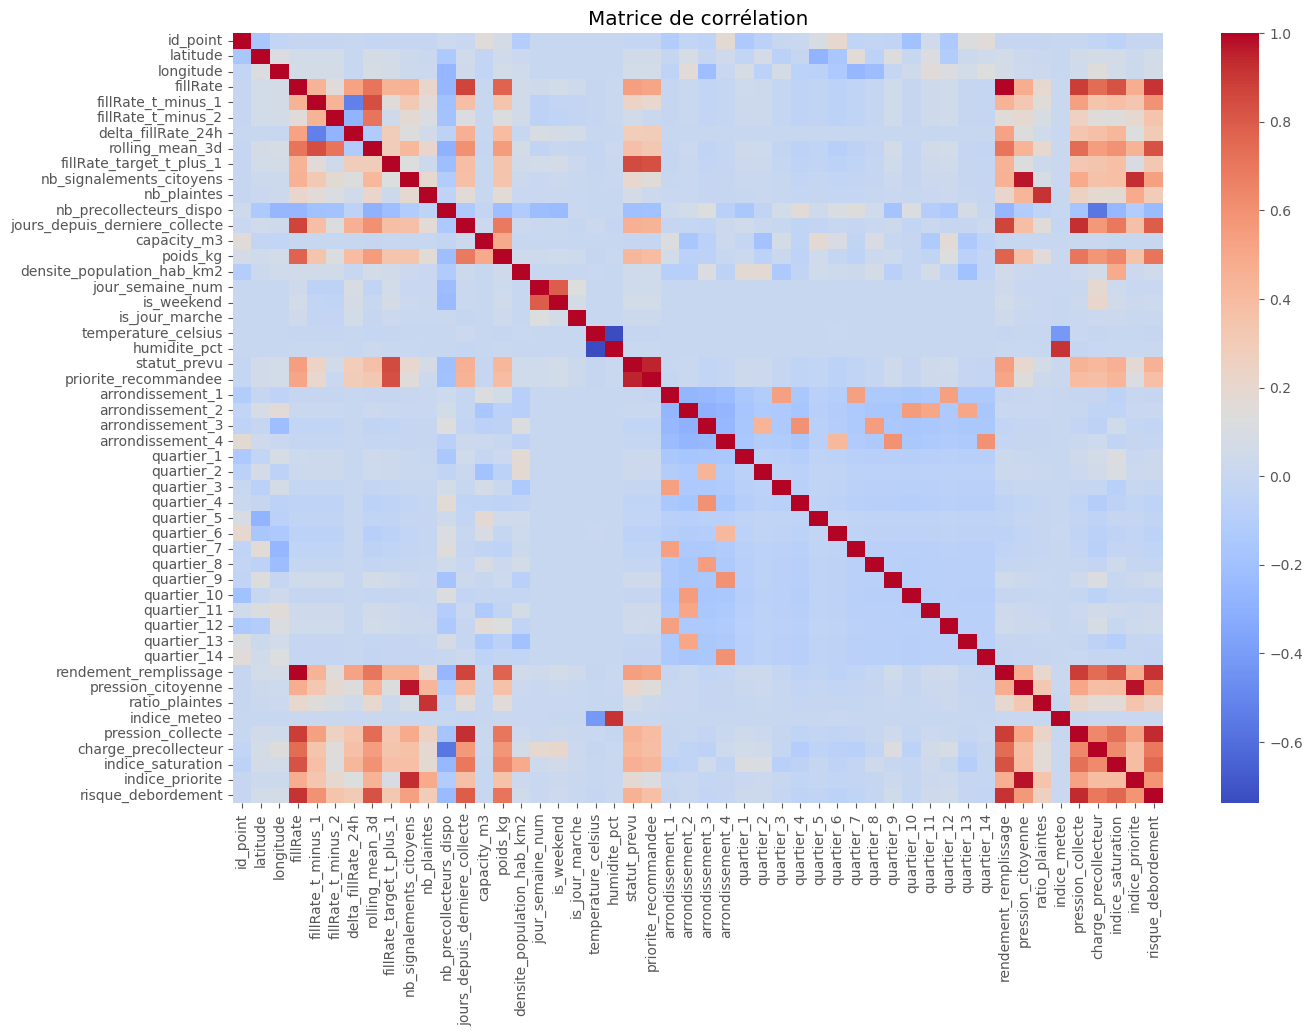

In [7]:

corr = data.corr(numeric_only=True)

corr["fillRate_target_t_plus_1"]\
.sort_values(ascending=False)

# Heatmap

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()

#### Analyse temporelle

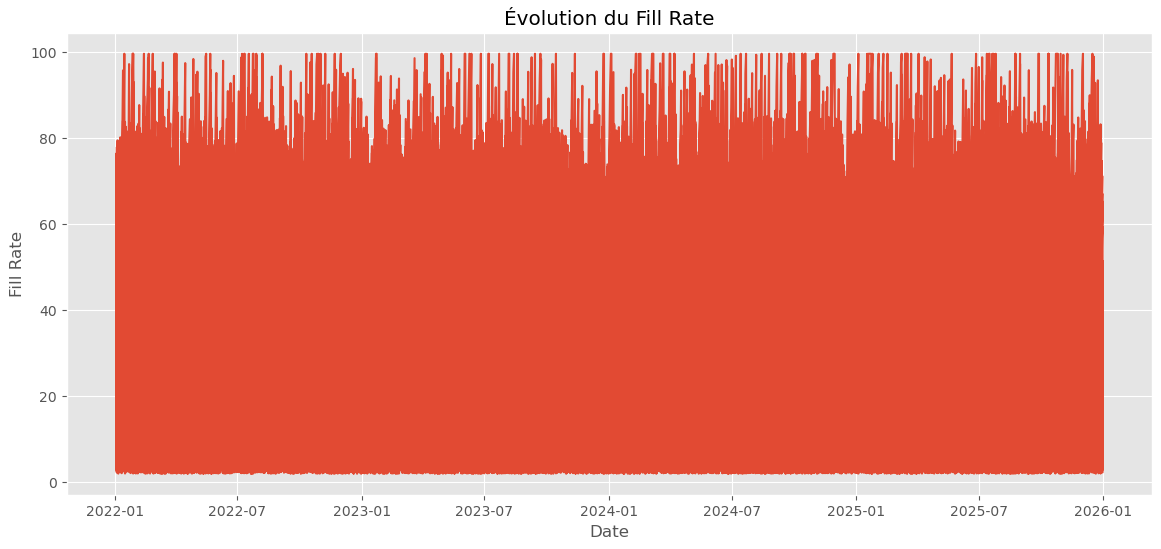

In [10]:
data["date_collecte"] = pd.to_datetime(
    data["date_collecte"]
)

#Évolution du Fill Rate

plt.figure(figsize=(14,6))

plt.plot(
    data["date_collecte"],
    data["fillRate"]
)

plt.title("Évolution du Fill Rate")

plt.xlabel("Date")

plt.ylabel("Fill Rate")

plt.show()


#### Analyse des nouvelles variables

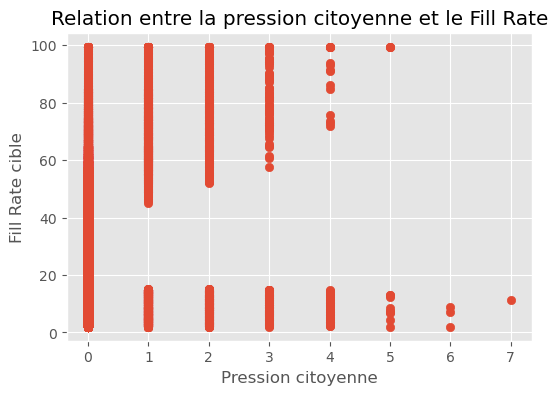

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(
    data["pression_citoyenne"],
    data["fillRate_target_t_plus_1"]
)

plt.xlabel("Pression citoyenne")

plt.ylabel("Fill Rate cible")

plt.title("Relation entre la pression citoyenne et le Fill Rate")

plt.show()

#### Pression de collecte

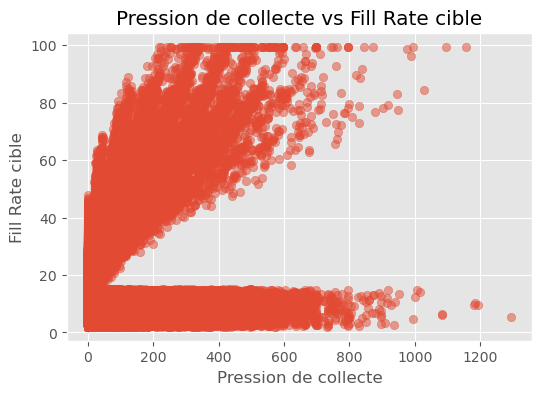

In [13]:

plt.figure(figsize=(6,4))

plt.scatter(
    data["pression_collecte"],
    data["fillRate_target_t_plus_1"],
    alpha=0.5
)

plt.title("Pression de collecte vs Fill Rate cible")
plt.xlabel("Pression de collecte")
plt.ylabel("Fill Rate cible")

plt.show()

#### Indice de saturation

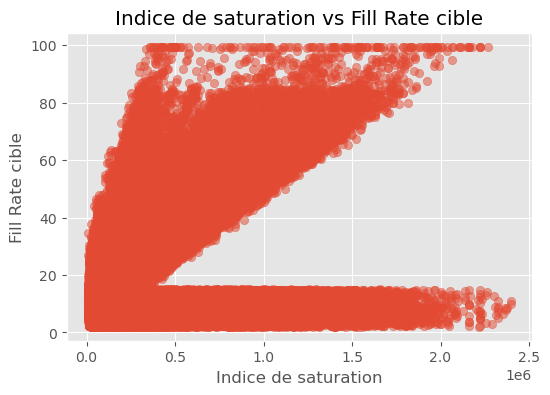

In [14]:

plt.figure(figsize=(6,4))

plt.scatter(
    data["indice_saturation"],
    data["fillRate_target_t_plus_1"],
    alpha=0.5
)

plt.title("Indice de saturation vs Fill Rate cible")
plt.xlabel("Indice de saturation")
plt.ylabel("Fill Rate cible")

plt.show()

#### Charge par précollecteur

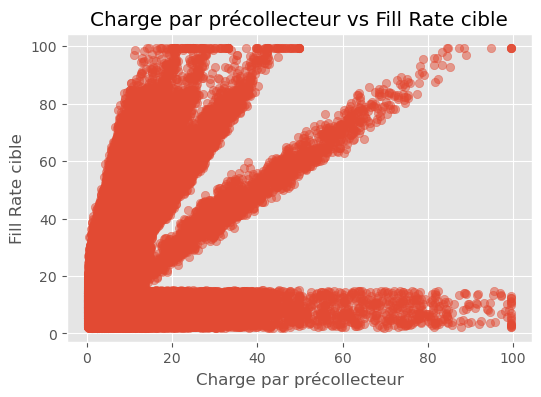

In [15]:

plt.figure(figsize=(6,4))

plt.scatter(
    data["charge_precollecteur"],
    data["fillRate_target_t_plus_1"],
    alpha=0.5
)

plt.title("Charge par précollecteur vs Fill Rate cible")
plt.xlabel("Charge par précollecteur")
plt.ylabel("Fill Rate cible")

plt.show()

#### Risque de débordement

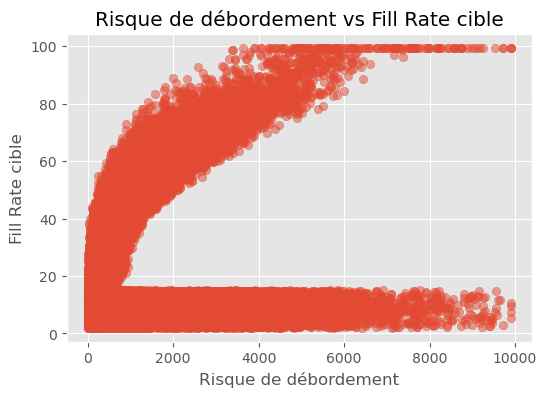

In [16]:
plt.figure(figsize=(6,4))

plt.scatter(
    data["risque_debordement"],
    data["fillRate_target_t_plus_1"],
    alpha=0.5
)

plt.title("Risque de débordement vs Fill Rate cible")
plt.xlabel("Risque de débordement")
plt.ylabel("Fill Rate cible")

plt.show()

In [18]:
corr = data.corr(numeric_only=True)

print(
    corr["fillRate_target_t_plus_1"]
    .sort_values(ascending=False)
)

fillRate_target_t_plus_1          1.000000
statut_prevu                      0.849539
priorite_recommandee              0.832968
fillRate                          0.448683
rendement_remplissage             0.446511
jours_depuis_derniere_collecte    0.384874
indice_saturation                 0.378498
poids_kg                          0.351719
charge_precollecteur              0.343349
pression_collecte                 0.334627
risque_debordement                0.324578
delta_fillRate_24h                0.282743
rolling_mean_3d                   0.281957
fillRate_t_minus_1                0.151774
nb_signalements_citoyens          0.125493
pression_citoyenne                0.122465
indice_priorite                   0.102673
is_weekend                        0.074497
longitude                         0.065745
latitude                          0.060865
jour_semaine_num                  0.059991
densite_population_hab_km2        0.052234
quartier_9                        0.047729
quartier_12